## Clean WDM Retrieval Notebook

# This notebook is a thin Jupyter wrapper around `wdm_retrieval_clean.py`.

#It keeps the retrieval logic clean and avoids the earlier `numpy.ndarray` issue with `wdm.csvtowdm` by ensuring all WDM inputs remain pandas objects with a `DatetimeIndex`.

#**Before running this notebook:** make sure your Earthdata credentials and token setup are already working in your environment.

In [28]:
import requests
import io
import pandas
import numpy as np
#import matplotlib.pyplot as plt
from subprocess import Popen
import platform
import os
import shutil
from getpass import getpass
import netrc
from base64 import b64encode
#import earthaccess

In [29]:
import importlib
import os
import pandas as pd
from pathlib import Path

import wdm_retrieval_clean as wrc

importlib.reload(wrc)
print("Loaded from:", wrc.__file__)

Loaded from: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\wdm_retrieval_clean.py


## Edit these parameters

#You can point `station_csv` to your own station list, or keep the provided example file.

In [30]:
import pandas as pd

workspace = Path.cwd()
station_csv = workspace / "station_example.csv"
start_date = "2023-01-01"
end_date = "2023-12-31"
wdm_file = workspace / "MetData_clean_notebook_042326a.wdm"
log_file = workspace / "MetLog_clean_notebook_042326a.txt"
print(f"Workspace: {workspace}")
print(f"Station CSV: {station_csv}")
print(f"Date range: {start_date} to {end_date}")
print(f"WDM output: {wdm_file}")
print(f"Log output: {log_file}")

Workspace: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS
Station CSV: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\station_example.csv
Date range: 2023-01-01 to 2023-12-31
WDM output: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\MetData_clean_notebook_042326a.wdm
Log output: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\MetLog_clean_notebook_042326a.txt


## Preview stations and dataset selection
##"This cell validates the station file and shows whether each station will use NLDAS or GLDAS."

In [31]:
stations = wrc.load_stations(station_csv)
preview_rows = []
for station in stations:
    catalog, timestep_hours, dataset_name = wrc.get_catalog(station)
    preview_rows.append({
        "StationName": station.name,
        "Latitude": station.latitude,
        "Longitude": station.longitude,
        "TimeZoneAdjustment": station.timezone_adjustment,
        "Dataset": dataset_name,
        "TimeStepHours": timestep_hours,
    })
pd.DataFrame(preview_rows)

,StationName,Latitude,Longitude,TimeZoneAdjustment,Dataset,TimeStepHours
0,CentralPark,40.785091,-73.968285,-5.0,NLDAS,1
1,GoldenGate,37.819929,-122.478255,-8.0,NLDAS,1
2,MillenniumPark,41.882702,-87.619392,-6.0,NLDAS,1


## Constituents to be written
##These are the constituents handled by the clean workflow

In [5]:
wrc.CONSTITUENTS

['ATEMP', 'PRECIP', 'SOLR', 'WIND', 'CLOU', 'DEWP', 'ATMP']

## Preview DEWP calculation
##This cell fetches and previews the computed dew point timeseries for the first station before the full WDM run.

In [6]:
wrc.ensure_earthdata_credentials()

if not stations:
    raise ValueError("No stations were loaded from the station CSV.")

dewp_preview_result = wrc.build_result_for_constituent(
    station=stations[0],
    constituent="DEWP",
    start_date=start_date,
    end_date=end_date,
)

print(f"Preview station: {stations[0].name}")
print(f"DEWP source variables: {dewp_preview_result.variable_name}")
dewp_preview_result.series.to_frame(name="DEWP").head()

Preview station: CentralPark
DEWP source variables: NLDAS:NLDAS_FORA0125_H_2_0_Qair + NLDAS:NLDAS_FORA0125_H_2_0_Tair + NLDAS:NLDAS_FORA0125_H_2_0_PSurf


,DEWP
Datetime:UTC,
2023-01-01 00:00:00+00:00,43.591304
2023-01-01 01:00:00+00:00,43.466921
2023-01-01 02:00:00+00:00,43.347626
2023-01-01 03:00:00+00:00,43.227251
2023-01-01 04:00:00+00:00,43.080060


In [7]:
wrc.ensure_earthdata_credentials()

if not stations:
    raise ValueError("No stations were loaded from the station CSV.")

atemp_preview_result = wrc.build_result_for_constituent(
    station=stations[0],
    constituent="ATEMP",
    start_date=start_date,
    end_date=end_date,
)

print(f"Preview station: {stations[0].name}")
print(f"ATEMP source variables: {atemp_preview_result.variable_name}")
atemp_preview_result.series.to_frame(name="ATEMP").head()

Preview station: CentralPark
ATEMP source variables: NLDAS:NLDAS_FORA0125_H_2_0_Tair


,ATEMP
Datetime:UTC,
2023-01-01 00:00:00+00:00,46.598
2023-01-01 01:00:00+00:00,46.400
2023-01-01 02:00:00+00:00,46.184
2023-01-01 03:00:00+00:00,45.968
2023-01-01 04:00:00+00:00,45.716


In [9]:
atemp_preview_result.series.to_frame(name="ATEMP").describe()

,ATEMP
count,8737.000000
mean,55.917548
std,15.514124
min,3.506000
25%,42.890000
50%,55.040000
75%,69.026000
max,94.100000


<Axes: xlabel='Datetime:UTC'>

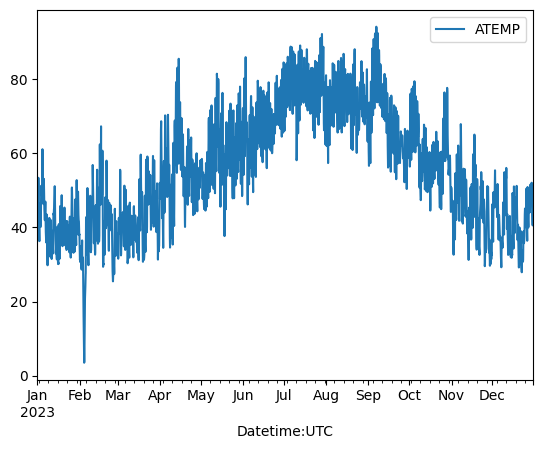

In [21]:
import matplotlib as plt 
#atemp_preview_result.series.to_frame(name="ATEMP").info()

atemp_preview_result.series.to_frame(name="ATEMP").plot(y="ATEMP")

## Run retrieval and write the WDM file
##"This cell will call the clean retrieval pipeline, build the WDM file, and create the MetLog text file.

In [22]:
wrc.ensure_earthdata_credentials()

if not stations:
    raise ValueError("No stations were loaded from the station CSV.")

precip_preview_result = wrc.build_result_for_constituent(
    station=stations[0],
    constituent="PRECIP",
    start_date=start_date,
    end_date=end_date,
)

print(f"Preview station: {stations[0].name}")
print(f"ATEMP source variables: {precip_preview_result.variable_name}")
precip_preview_result.series.to_frame(name="PRECIP").head()

Preview station: CentralPark
ATEMP source variables: NLDAS:NLDAS_FORA0125_H_2_0_Rainf


,PRECIP
Datetime:UTC,
2023-01-01 00:00:00+00:00,0.0150
2023-01-01 01:00:00+00:00,0.5811
2023-01-01 02:00:00+00:00,0.8643
2023-01-01 03:00:00+00:00,2.4640
2023-01-01 04:00:00+00:00,0.9662


In [23]:
precip_preview_result.series.to_frame(name="PRECIP").describe()

,PRECIP
count,8737.000000
mean,0.173424
std,0.950031
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,23.431800


<Axes: xlabel='Datetime:UTC'>

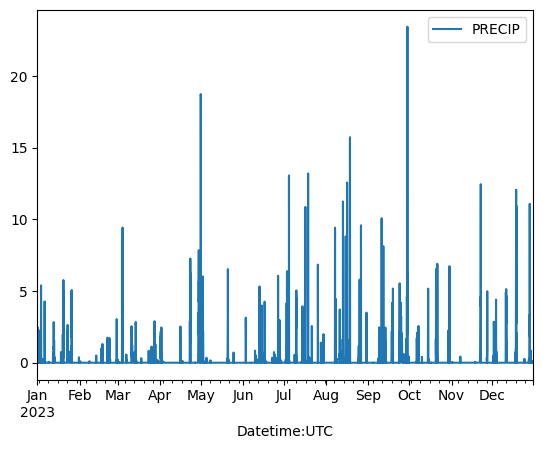

In [25]:
import matplotlib as plt 
#atemp_preview_result.series.to_frame(name="ATEMP").info()

precip_preview_result.series.to_frame(name="PRECIP").plot(y="PRECIP")

In [32]:
wrc.ensure_earthdata_credentials()

if not stations:
    raise ValueError("No stations were loaded from the station CSV.")

precip_preview_result = wrc.build_result_for_constituent(
    station=stations[1],
    constituent="PRECIP",
    start_date=start_date,
    end_date=end_date,
)

print(f"Preview station: {stations[1].name}")
print(f"ATEMP source variables: {precip_preview_result.variable_name}")
precip_preview_result.series.to_frame(name="PRECIP").head()

Preview station: GoldenGate
ATEMP source variables: NLDAS:NLDAS_FORA0125_H_2_0_Rainf


,PRECIP
Datetime:UTC,
2023-01-01 00:00:00+00:00,8.9137
2023-01-01 01:00:00+00:00,0.0609
2023-01-01 02:00:00+00:00,0.0695
2023-01-01 03:00:00+00:00,0.1226
2023-01-01 04:00:00+00:00,0.2607


In [33]:
precip_preview_result.series.to_frame(name="PRECIP").describe()

,PRECIP
count,8737.000000
mean,0.093037
std,1.121098
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,98.553400


<Axes: xlabel='Datetime:UTC'>

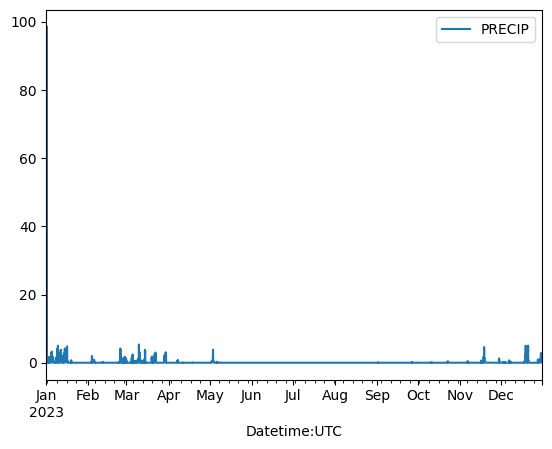

In [34]:
precip_preview_result.series.to_frame(name="PRECIP").plot(y="PRECIP")

In [36]:
created_wdm, created_log = wrc.run_retrieval(stations=stations, start_date=start_date, end_date=end_date, wdm_path=wdm_file, log_path=log_file)
print(f"Created WDM file: {created_wdm}")
print(f"Created log file: {created_log}")

Created WDM file: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\MetData_clean_notebook_042226b.wdm
Created log file: C:\Users\KVENABLE\NLDASV2_Giovanni_BASINS\MetLog_clean_notebook_042226b.txt


## Quick output check

In [37]:
print("WDM exists:", Path(created_wdm).exists())
print("Log exists:", Path(created_log).exists())

if Path(created_log).exists():
    with open(created_log, "r", encoding="utf-8") as f:
        log_preview = f.readlines()[:15]
    print("".join(log_preview))

WDM exists: True
Log exists: True
Started downloading data at 2026-04-22T13:10:53.985603 and saving in MetData_clean_notebook_042226b.wdm
Station: CentralPark, Latitude: 40.785091, Longitude: -73.968285, TimeZoneAdjustment: -5.0
Constituent: ATEMP, Column Name: ATEMP, DSN: 1
Constituent: PRECIP, Column Name: PRECIP, DSN: 2
Constituent: SOLR, Column Name: SOLR, DSN: 3
Constituent: WIND, Column Name: WIND, DSN: 4
Constituent: CLOU, Column Name: CLOU, DSN: 5
Constituent: DEWP, Column Name: DEWP, DSN: 6
Constituent: ATMP, Column Name: ATMP, DSN: 7
Station: GoldenGate, Latitude: 37.819929, Longitude: -122.478255, TimeZoneAdjustment: -8.0
Constituent: ATEMP, Column Name: ATEMP, DSN: 8
Constituent: PRECIP, Column Name: PRECIP, DSN: 9
Constituent: SOLR, Column Name: SOLR, DSN: 10
Constituent: WIND, Column Name: WIND, DSN: 11
Constituent: CLOU, Column Name: CLOU, DSN: 12

